In [54]:
import os

from basic_training_loops import current_loss

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
X = np.arange(-500, 500, 4)
y = X * 2 + 5
len(X), len(y)

(250, 250)

In [3]:
X_train = X[:200]
X_test = X[200:]
y_train = y[:200]
y_test = y[200:]

In [4]:
tf.random.set_seed(42)

model_0 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1, )),
    tf.keras.layers.Dense(1),
])

model_0.compile(
    loss=tf.keras.losses.mae,
    optimizer=tf.keras.optimizers.Adam(),
    metrics=['mae']
)

model_0.fit(X_train, y_train, epochs=100, verbose=0)


In [5]:
y_preds_0 = model_0.predict(X_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


In [6]:
def plot_model(
        train_data=X_train,
        train_labels=y_train,
        test_data=X_test,
        test_labels=y_test,
        preds=y_preds_0
):
    plt.figure(figsize=(10, 7))
    plt.scatter(train_data, train_labels, c='b', label='Training data')
    plt.scatter(test_data, test_labels, c='g', label='Test data')
    plt.scatter(test_data, preds, c='r', label='Predictions')
    plt.legend()

In [7]:
@tf.function
def mae(y_true, y_pred):
    return tf.metrics.mae(y_true, y_pred)

@tf.function
def mse(y_true, y_pred):
    return tf.metrics.mse(y_true, y_pred)

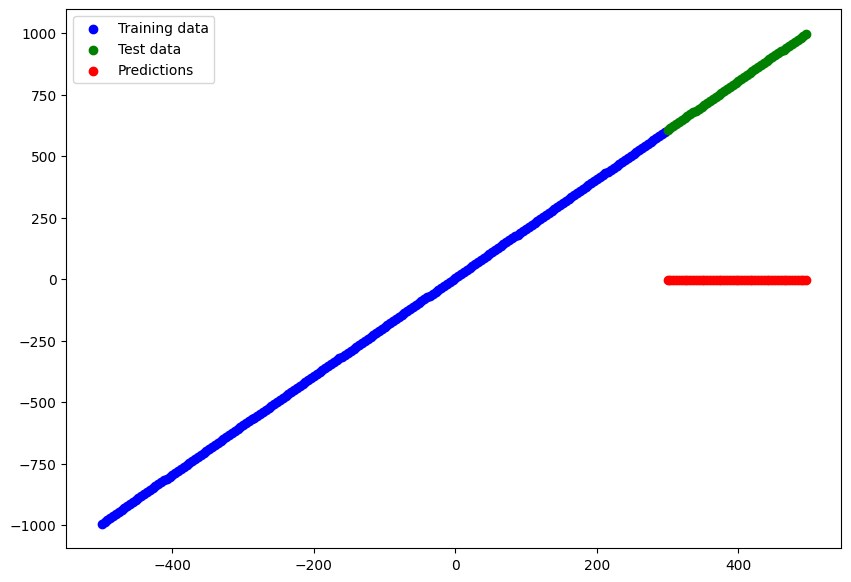

In [8]:
plot_model(
    train_data=X_train,
    train_labels=y_train,
    test_data=X_test,
    test_labels=y_test,
    preds=y_preds_0
)

In [9]:
mae_0 = mae(y_test, y_preds_0.squeeze()).numpy()
mse_0 = mse(y_test, y_preds_0.squeeze()).numpy()
mae_0, mse_0

(np.float32(804.7693), np.float32(661088.9))

In [10]:
tf.random.set_seed(42)

model_1 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1, )),
    tf.keras.layers.Dense(4),
    tf.keras.layers.Dense(1)
])

model_1.compile(loss=tf.keras.losses.mae,
                optimizer=tf.keras.optimizers.Adam(),
                metrics=['mae'])

model_1.fit(X_train, y_train, epochs=500, verbose=0)


In [11]:
y_preds_1 = model_1.predict(X_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


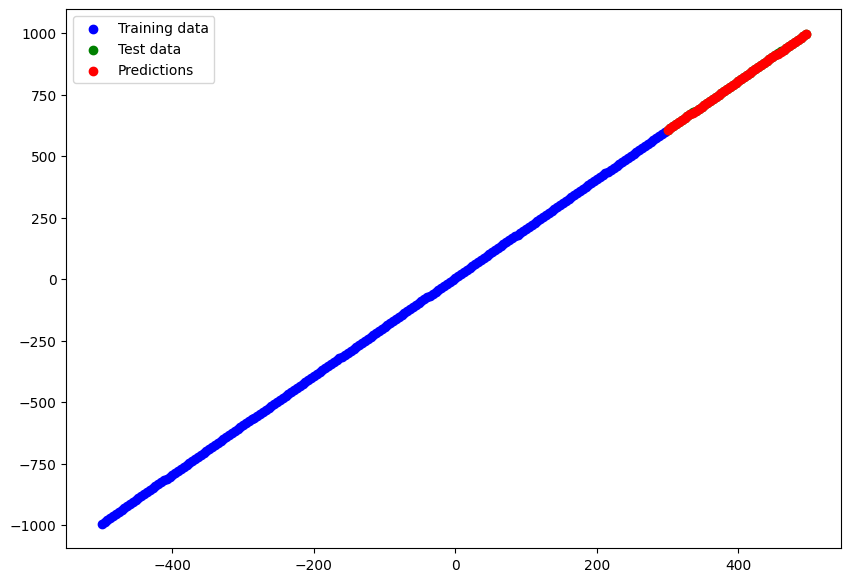

In [12]:
plot_model(preds=y_preds_1)

In [13]:
mae_1 = mae(y_test, y_preds_1.squeeze()).numpy()
mse_1 = mse(y_test, y_preds_1.squeeze()).numpy()
mae_1, mse_1

(np.float32(0.17543702), np.float32(0.03150184))

In [14]:
tf.random.set_seed(42)

model_2 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1,)),
    tf.keras.layers.Dense(4),
    tf.keras.layers.Dense(4),
    tf.keras.layers.Dense(1)
])

model_2.compile(loss=tf.keras.losses.mae,
                optimizer=tf.keras.optimizers.Adam(),
                metrics=['mae'])

model_2.fit(X_train, y_train, epochs=500, verbose=0)

In [15]:
y_preds_2 = model_2.predict(X_test)

1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/stepWARNING:tensorflow:6 out of the last 6 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x7528c049db20> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


In [16]:
mae_2 = mae(y_test, y_preds_2.squeeze()).numpy()
mse_2 = mse(y_test, y_preds_2.squeeze()).numpy()
mae_2, mse_2

(np.float32(1.193313), np.float32(1.454355))

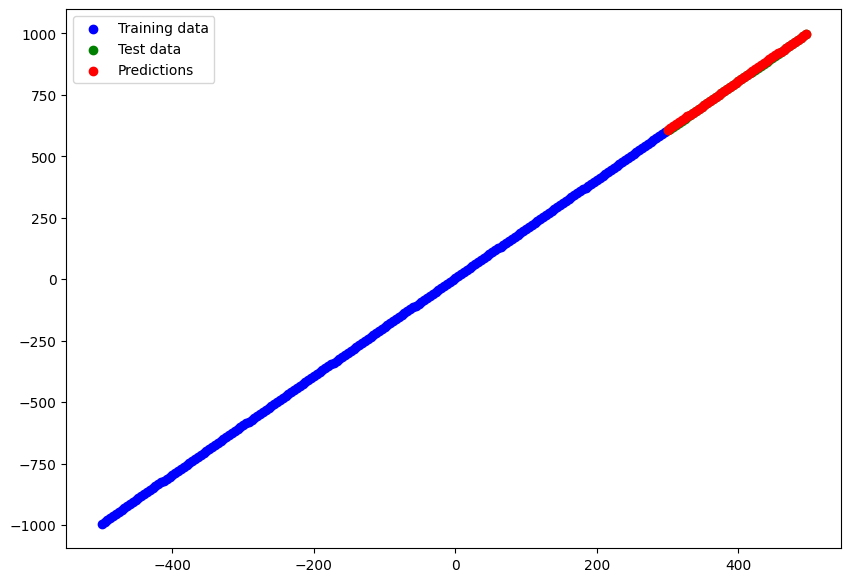

In [17]:
plot_model(preds=y_preds_2)

In [18]:
tf.random.set_seed(42)

model_3 = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(1,)),
    tf.keras.layers.Dense(16),
    tf.keras.layers.Dense(4),
    tf.keras.layers.Dense(1)
])

model_3.compile(loss=tf.keras.losses.mae,
                optimizer=tf.keras.optimizers.Adam(),
                metrics=['mae'])

model_3.fit(X_train, y_train, epochs=500, verbose=0)

In [19]:
y_preds_3 = model_3.predict(X_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


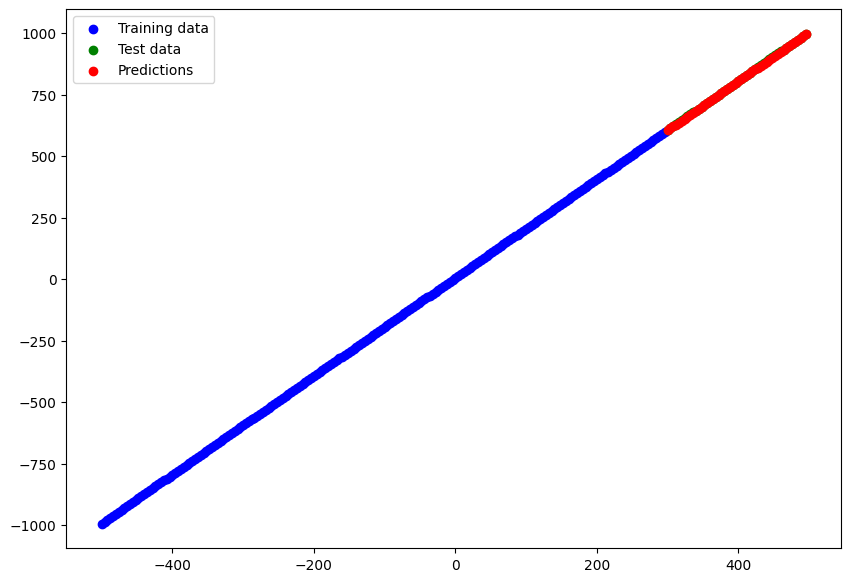

In [20]:
plot_model(preds=y_preds_3)

In [21]:
mae_3 = mae(y_test, y_preds_3.squeeze()).numpy()
mse_3 = mse(y_test, y_preds_3.squeeze()).numpy()
mae_3, mse_3

(np.float32(1.0992273), np.float32(1.2342604))

In [22]:
model_results = [["model_0", mae_0, mse_0],
                 ["model_1", mae_1, mse_1],
                 ["model_2", mae_2, mse_2],
                 ["model_3", mae_3, mse_3]]

In [23]:
all_results = pd.DataFrame(model_results, columns=["model", "mae", "mse"])
all_results

,model,mae,mse
0,model_0,804.769287,661088.875000
1,model_1,0.175437,0.031502
2,model_2,1.193313,1.454355
3,model_3,1.099227,1.234260


In [39]:
x = np.arange(-500, 500, 4)
noise = np.random.randint(-5, 5, (len(x)))
def f(x):
    return 2 * x + 3

y = f(x) + noise

In [40]:
len(x), len(y)

(250, 250)

In [42]:
x.shape, y.shape

((250,), (250,))

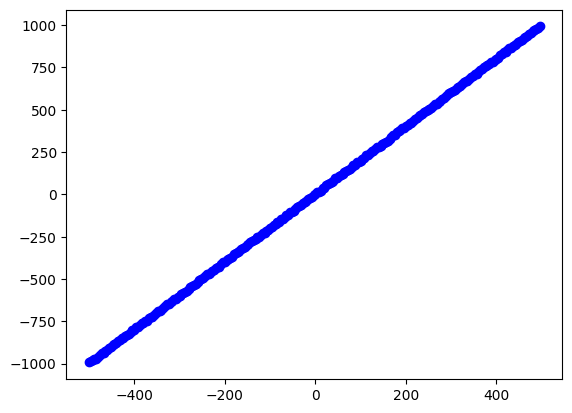

In [43]:
plt.scatter(x, y, c='b', label='data')

In [46]:
class Model(tf.Module):
    def __init__(self):
        super().__init__()
        self.w = tf.Variable(np.random.randn())
        self.b = tf.Variable(np.random.randn())

    def __call__(self, x):
        return self.w * x + self.b

In [48]:
model = Model()

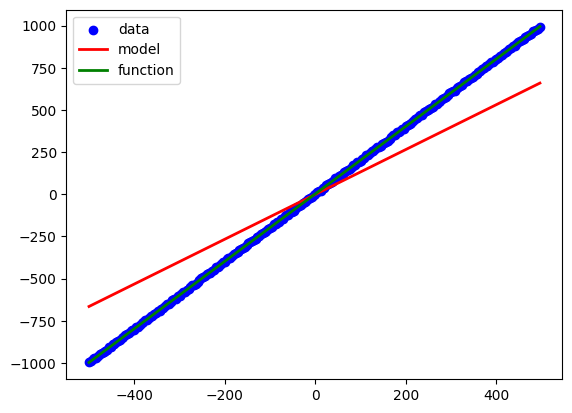

In [50]:
plt.scatter(x, y, c='b', label='data')
plt.plot(x, model(x), c='r', label='model',lw=2)
plt.plot(x, f(x), c='g', label='function',lw=2)
plt.legend()
plt.show()

In [51]:
def loss(y_true, y_pred):
    return tf.reduce_mean(tf.square(y_true - y_pred))

In [53]:
def train(model, x, y, learning_rate):
    with tf.GradientTape() as tape:
        current_loss = loss(y, model(x))
    dw, db = tape.gradient(current_loss, [model.w, model.b])
    model.w.assign_sub(learning_rate * dw)
    model.b.assign_sub(learning_rate * db)

In [55]:
model = Model()
weights = []
biases = []
epochs = range(10)

def report(model, loss):
    return f"W={model.w.numpy(): 1.2f}, b={model.b.numpy(): 1.2f}, loss={loss.numpy(): 2.5f}"


def training_loop(model, x, y):
    for epoch in epochs:
        train(model, x, y, learning_rate=0.1)
        weights.append(model.w.numpy())
        biases.append(model.b.numpy())
        current_loss = loss(y, model(x))
        print(f"Epoch {epoch: 2d}:")
        print(f"{report(model, current_loss)}")
        

In [56]:
training_loop(model, x, y)

Epoch  0:
W= 42845.25, b=-0.84, loss= 152966921191424.00000
Epoch  1:
W=-714034240.00, b= 17137.14, loss= 42488436065291036786688.00000
Epoch  2:
W= 11900237643776.00, b=-285600608.00, loss= 11801683757879642217499353677824.00000
Epoch  3:
W=-198331745664237568.00, b= 4759877058560.00, loss= inf
Epoch  4:
W= 3305436649756945285120.00, b=-79329016619728896.00, loss= inf
Epoch  5:
W=-55089070577193062447972352.00, b= 1322113298357855191040.00, loss= inf
Epoch  6:
W= 918125513914065459019713085440.00, b=-22034621960988004123148288.00, loss= inf
Epoch  7:
W=-15301663080490282145213991396311040.00, b= 367233922845993249071188410368.00, loss= inf
Epoch  8:
W= inf, b=-6120391028477411146354706402508800.00, loss= nan
Epoch  9:
W= nan, b= nan, loss= nan
